<a href="https://colab.research.google.com/github/AnhThu150407/BTVN-AI-01/blob/main/BTVN_AI_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#23.1
import folium

map = folium.Map(location=[10.762622, 106.660172], zoom_start=15)

folium.Marker(
    location=[10.762622, 106.660172],
    popup="UEH - Đại học Kinh tế TP.HCM",
    tooltip="Click vào đây"
).add_to(map)

locations = [
    [10.7620, 106.6605, "Thư viện"],
    [10.7630, 106.6610, "Trung tâm thương mại"],
    [10.7615, 106.6595, "Bãi xe"]
]

for lat, lon, name in locations:
    folium.Marker([lat, lon], popup=name).add_to(map)

map

In [ ]:
#23.2
!pip install folium geopy

import folium
from geopy.distance import geodesic

locations = [
    ("UEH", (10.762622,106.660172)),
    ("Ben Thanh", (10.772,106.698)),
    ("Landmark 81", (10.795,106.721)),
    ("Tan Son Nhat Airport", (10.818,106.652)),
    ("Saigon Centre", (10.773,106.701)),
    ("Dinh Doc Lap", (10.777,106.695)),
    ("Nha Tho Duc Ba", (10.779,106.699)),
    ("Vincom Dong Khoi", (10.778,106.702)),
    ("Pho Tay Bui Vien", (10.767,106.693)),
    ("Thao Cam Vien", (10.787,106.705))
]

center = locations[0][1]

m = folium.Map(location=center, zoom_start=13)

print("\nKhoảng cách từ UEH:\n")
for name, coord in locations:
    dist = geodesic(center, coord).km
    print(f"{name}: {dist:.2f} km")

    folium.Marker(
        location=coord,
        popup=f"{name}\n{dist:.2f} km",
        icon=folium.Icon(color="blue")
    ).add_to(m)

folium.Marker(
    location=center,
    popup="Trung tâm (UEH)",
    icon=folium.Icon(color="red")
).add_to(m)

for name, coord in locations:
    folium.PolyLine([center, coord], color="green").add_to(m)

m


Khoảng cách từ UEH:

UEH: 0.00 km
Ben Thanh: 4.27 km
Landmark 81: 7.56 km
Tan Son Nhat Airport: 6.19 km
Saigon Centre: 4.61 km
Dinh Doc Lap: 4.13 km
Nha Tho Duc Ba: 4.62 km
Vincom Dong Khoi: 4.88 km
Pho Tay Bui Vien: 3.62 km
Thao Cam Vien: 5.60 km


In [ ]:
#23.3
import folium
from folium.plugins import HeatMap

delivery_points = [
    [10.762, 106.682],
    [10.751, 106.674],
    [10.768, 106.708],
    [10.780, 106.695],
    [10.770, 106.690],
    [10.785, 106.710],
    [10.760, 106.720],
    [10.775, 106.705],
    [10.790, 106.700],
    [10.755, 106.680]
]

m = folium.Map(location=[10.775, 106.700], zoom_start=13)

HeatMap(delivery_points, radius=25, blur=15).add_to(m)

for point in delivery_points:
    folium.Marker(point).add_to(m)

m


In [10]:
#23.4
import folium
import pandas as pd
import json

geo_data_path = "/content/district-boundary-hcm-city (1) (1).geojson"
excel_data_path = "/content/btvn.xlsx"

try:
    with open(geo_data_path, 'r', encoding='utf-8') as f:
        geo_data = json.load(f)

    df = pd.read_excel(excel_data_path)

    def fix_name(x):
        x = str(x).strip()
        x = x.replace("District", "").strip()
        if x.isdigit():
            return f"District {x}"
        return x

    df['Ten_Mapping'] = df['Tinh'].apply(fix_name)

    m = folium.Map(location=[10.776, 106.700], zoom_start=11)

    folium.Choropleth(
        geo_data=geo_data,
        data=df,
        columns=["Ten_Mapping", "Dan so"],
        key_on="feature.properties.name",
        fill_color="YlOrRd",
        fill_opacity=0.7,
        line_opacity=0.5,
        nan_fill_color="grey",
        legend_name="Dân số"
    ).add_to(m)
    population_dict = df.set_index('Ten_Mapping')['Dan so'].to_dict()

    for feature in geo_data['features']:
        name_in_geo = feature['properties'].get('name', '')
        val = population_dict.get(name_in_geo, 0)
        feature['properties']['dan_so_hien_thi'] = val

    folium.GeoJson(
        geo_data,
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 0.5},
        tooltip=folium.GeoJsonTooltip(
            fields=['name', 'dan_so_hien_thi'],
            aliases=['Quận/Huyện:', 'Dân số:'],
            localize=True
        )
    ).add_to(m)

    display(m)

except Exception as e:
    print(f"Lỗi: {e}")

In [ ]:
#23.5
!pip install folium geopy

import folium
from geopy.distance import geodesic

center = (10.776, 106.700)

m = folium.Map(location=center, zoom_start=13)
for radius in [3000, 5000, 10000]:
    folium.Circle(
        location=center,
        radius=radius,
        color="blue",
        fill=True,
        fill_opacity=0.1,
        popup=f"Bán kính {radius/1000} km"
    ).add_to(m)

customers = [
    (10.780, 106.705),
    (10.770, 106.690),
    (10.765, 106.710),
    (10.750, 106.680),
    (10.790, 106.720),
]

for i, cust in enumerate(customers, 1):
    folium.Marker(
        location=cust,
        popup=f"Khách hàng {i}"
    ).add_to(m)

m



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.0 MB/s eta 0:00:00
Số node (giao lộ): 985
Số edge (đường): 2081


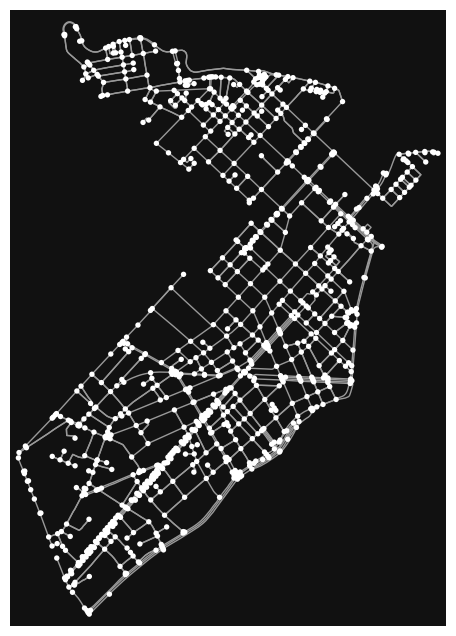

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
#23.6
!pip install osmnx

import osmnx as ox

place = "District 1, Ho Chi Minh City, Vietnam"

G = ox.graph_from_place(
    place,
    network_type="drive"
)

print("Số node (giao lộ):", len(G.nodes))
print("Số edge (đường):", len(G.edges))

ox.plot_graph(G)

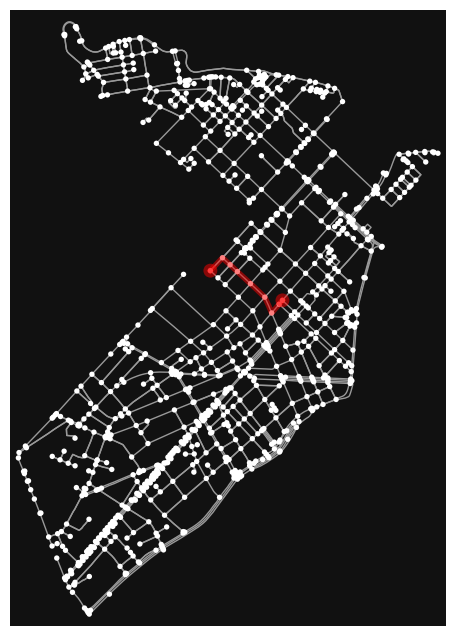

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
#23.7
!pip install osmnx networkx

import osmnx as ox
import networkx as nx

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")

origin = (10.7769, 106.7009)
destination = (10.7800, 106.6950)

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

route = nx.shortest_path(G, orig_node, dest_node, weight='length')

ox.plot_graph_route(G, route)

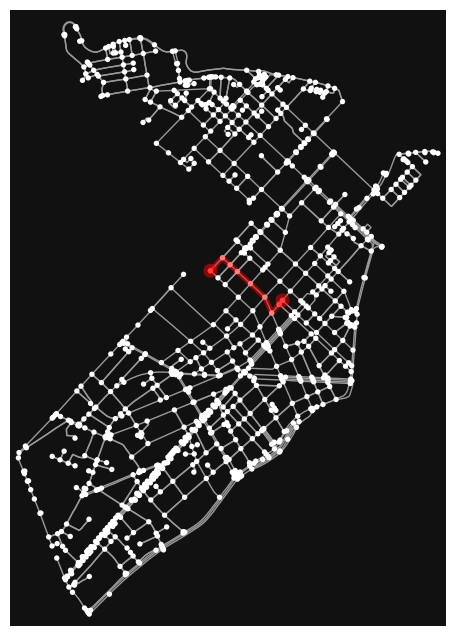

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
#23.7
!pip install osmnx networkx

import osmnx as ox
import networkx as nx

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")

origin = (10.7769, 106.7009)
destination = (10.7800, 106.6950)

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

def heuristic(u, v):
    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    return ((y1 - y2)**2 + (x1 - x2)**2) ** 0.5
route = nx.astar_path(
    G,
    orig_node,
    dest_node,
    heuristic=heuristic,
    weight='length'
)

ox.plot_graph_route(G, route)

In [ ]:
#23.8
!pip install folium geopy

import folium
from geopy.distance import geodesic

customer = ("Khách hàng", (10.7769, 106.7009))

drivers = [
    ("Xe 1", (10.7800, 106.6950)),
    ("Xe 2", (10.7700, 106.7100)),
    ("Xe 3", (10.7650, 106.6900))
]

distances = []
for name, coord in drivers:
    dist = geodesic(customer[1], coord).km
    distances.append((name, coord, dist))

best_driver = min(distances, key=lambda x: x[2])

m = folium.Map(location=customer[1], zoom_start=14)

folium.Marker(
    location=customer[1],
    popup="Khách hàng",
    icon=folium.Icon(color="red")
).add_to(m)

for name, coord, dist in distances:

    color = "green" if name == best_driver[0] else "blue"
    radius = 8 if name == best_driver[0] else 5

    folium.CircleMarker(
        location=coord,
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"{name}: {dist:.2f} km"
    ).add_to(m)

folium.PolyLine(
    [best_driver[1], customer[1]],
    color="green",
    weight=5
).add_to(m)
for name, coord, dist in distances:

    color = "green" if name == best_driver[0] else "gray"
    weight = 5 if name == best_driver[0] else 2

    folium.PolyLine(
        [coord, customer[1]],
        color=color,
        weight=weight,
        opacity=0.7
    ).add_to(m)
m

In [ ]:
#23.9
!pip install folium scikit-learn

import folium
import numpy as np
from sklearn.cluster import KMeans

points = np.array([
    [10.762, 106.682],
    [10.751, 106.674],
    [10.768, 106.708],
    [10.780, 106.695],
    [10.770, 106.690],
    [10.785, 106.710],
    [10.760, 106.720],
    [10.775, 106.705],
    [10.790, 106.700],
    [10.755, 106.680]
])

k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(points)

centers = kmeans.cluster_centers_

m = folium.Map(location=[10.775, 106.700], zoom_start=13)

colors = ["red", "blue", "green"]

for i, point in enumerate(points):
    folium.CircleMarker(
        location=point,
        radius=6,
        color=colors[labels[i]],
        fill=True,
        fill_color=colors[labels[i]],
        fill_opacity=0.7,
        popup=f"KH {i+1} - Cụm {labels[i]+1}"
    ).add_to(m)

for i, point in enumerate(points):
    center = centers[labels[i]]

    folium.PolyLine(
        [point, center],
        color=colors[labels[i]],
        weight=2,
        opacity=0.5
    ).add_to(m)

for i, center in enumerate(centers):
    folium.Marker(
        location=center,
        popup=f"Kho đề xuất {i+1}",
        icon=folium.Icon(color="black")
    ).add_to(m)

m

In [ ]:
#23.10
import osmnx as ox
import networkx as nx
import folium

G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type="drive")

origin = (10.7769, 106.7009)
destination = (10.7800, 106.6950)

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

congested_points = [
    (10.778, 106.697, 90),
    (10.774, 106.705, 85)
]

for u, v, k, data in G.edges(keys=True, data=True):
    y = G.nodes[u]['y']
    x = G.nodes[u]['x']

    penalty = 1

    for cy, cx, level in congested_points:
        dist = ((y - cy)**2 + (x - cx)**2)**0.5

        if dist < 0.002:
            penalty = 3   # phạt vừa phải

    data['weight'] = data['length'] * penalty

route_normal = nx.shortest_path(G, orig_node, dest_node, weight='length')
route_alt = nx.astar_path(G, orig_node, dest_node, weight='weight')

m = folium.Map(location=origin, zoom_start=14)

for lat, lon, level in congested_points:
    folium.CircleMarker(
        location=[lat, lon],
        radius=10,
        color="red",
        fill=True,
        fill_color="red",
        popup=f"Tắc cao: {level}%"
    ).add_to(m)

def route_to_coords(route):
    return [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

folium.PolyLine(route_to_coords(route_normal), color="red", weight=4).add_to(m)

folium.PolyLine(route_to_coords(route_alt), color="green", weight=5).add_to(m)

folium.Marker(origin, icon=folium.Icon(color="blue")).add_to(m)
folium.Marker(destination, icon=folium.Icon(color="black")).add_to(m)

m

In [ ]:
#23.11
!pip install folium pandas scikit-learn

import folium
import pandas as pd
from sklearn.linear_model import LinearRegression

data = pd.DataFrame({
    'lat': [10.77, 10.78, 10.76, 10.75, 10.79, 10.74],
    'lon': [106.70, 106.69, 106.71, 106.68, 106.72, 106.73],
    'hour': [8, 9, 18, 19, 20, 21],
    'demand': [100, 120, 180, 160, 140, 130]
})

X = data[['lat', 'lon', 'hour']]
y = data['demand']

model = LinearRegression()
model.fit(X, y)

test_data = data.copy()
test_data['hour'] = 20
test_data['predicted'] = model.predict(test_data[['lat','lon','hour']])

m = folium.Map(location=[10.775,106.700], zoom_start=13)

for _, row in test_data.iterrows():

    demand = row['predicted']

    if demand >= 150:
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=10,
            color="red",
            fill=True,
            fill_color="red",
            popup=f"Nhu cầu cao: {int(demand)}"
        ).add_to(m)

m

In [ ]:
#23.12
!pip install folium pandas scikit-learn geopy

import folium
import pandas as pd
from sklearn.linear_model import LinearRegression
from geopy.distance import geodesic

customers = pd.DataFrame({
    'lat': [10.77, 10.78, 10.76],
    'lon': [106.70, 106.69, 106.71],
    'hour': [19, 19, 19]
})

train_data = pd.DataFrame({
    'lat': [10.77,10.78,10.76,10.75],
    'lon': [106.70,106.69,106.71,106.68],
    'hour': [8,12,18,20],
    'demand': [100,80,150,120]
})

X = train_data[['lat','lon','hour']]
y = train_data['demand']

model = LinearRegression()
model.fit(X,y)

customers['demand'] = model.predict(customers[['lat','lon','hour']])

drivers = [
    ("Xe 1", (10.775,106.695)),
    ("Xe 2", (10.770,106.710)),
    ("Xe 3", (10.765,106.690))
]

m = folium.Map(location=[10.775,106.700], zoom_start=14)

for i,row in customers.iterrows():
    if row['demand'] >= 120:

        folium.Marker(
            location=[row['lat'],row['lon']],
            popup=f"Khách {i+1} - Demand {int(row['demand'])}",
            icon=folium.Icon(color="red")
        ).add_to(m)

        best_driver = None
        min_dist = 999

        for name,coord in drivers:
            dist = geodesic((row['lat'],row['lon']),coord).km
            if dist < min_dist:
                min_dist = dist
                best_driver = (name,coord)

        folium.CircleMarker(
            location=best_driver[1],
            radius=8,
            color="green",
            fill=True,
            popup=f"{best_driver[0]}"
        ).add_to(m)

        folium.PolyLine(
            [best_driver[1], (row['lat'],row['lon'])],
            color="green",
            weight=5
        ).add_to(m)

m

In [ ]:
#23.13
!pip install folium

import folium

m = folium.Map(location=[10.775,106.700], zoom_start=14)

demand_layer = folium.FeatureGroup(name="Nhu cầu cao")
traffic_layer = folium.FeatureGroup(name="Tắc nghẽn")
driver_layer = folium.FeatureGroup(name="Xe")
route_layer = folium.FeatureGroup(name="Tuyến đường")

high_demand = [(10.77,106.70),(10.78,106.69)]

for lat,lon in high_demand:
    folium.CircleMarker(
        location=[lat,lon],
        radius=10,
        color="red",
        fill=True,
        fill_color="red"
    ).add_to(demand_layer)

congestion = [(10.778,106.697)]

for lat,lon in congestion:
    folium.CircleMarker(
        location=[lat,lon],
        radius=10,
        color="black",
        fill=True,
        fill_color="black"
    ).add_to(traffic_layer)

drivers = [(10.775,106.695),(10.770,106.710)]

for lat,lon in drivers:
    folium.CircleMarker(
        location=[lat,lon],
        radius=6,
        color="blue",
        fill=True,
        fill_color="blue"
    ).add_to(driver_layer)

route = [(10.775,106.695),(10.77,106.70)]

folium.PolyLine(
    route,
    color="green",
    weight=5
).add_to(route_layer)

demand_layer.add_to(m)
traffic_layer.add_to(m)
driver_layer.add_to(m)
route_layer.add_to(m)

folium.LayerControl().add_to(m)

m

In [ ]:
#23.14
!pip install folium

import folium
from folium.plugins import TimestampedGeoJson
import json
from datetime import datetime, timedelta

route = [
    (10.775,106.695),
    (10.774,106.697),
    (10.773,106.698),
    (10.772,106.699),
    (10.771,106.6995),
    (10.77,106.70)
]

features = []
start_time = datetime.now()

for i, point in enumerate(route):

    time = (start_time + timedelta(seconds=i*2)).isoformat()

    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [point[1], point[0]]
        },
        "properties": {
            "time": time,
            "icon": "circle",
            "iconstyle": {
                "fillColor": "blue",
                "fillOpacity": 0.8,
                "stroke": "true",
                "radius": 8
            },
            "popup": f"Xe - bước {i+1}"
        }
    })

m = folium.Map(location=route[0], zoom_start=15)

folium.PolyLine(route, color="green", weight=5).add_to(m)

folium.Marker(
    location=route[-1],
    icon=folium.Icon(color="red"),
    popup="Khách"
).add_to(m)

TimestampedGeoJson(
    {
        "type": "FeatureCollection",
        "features": features,
    },
    period="PT2S",
    add_last_point=True,
    auto_play=True,
    loop=False
).add_to(m)

m

In [ ]:
#23.15
!pip install folium

import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

def interpolate(p1, p2, steps=10):
    return [
        (
            p1[0] + (p2[0]-p1[0]) * i/steps,
            p1[1] + (p2[1]-p1[1]) * i/steps
        )
        for i in range(steps)
    ]

base_routes = [
    [(10.775,106.695),(10.770,106.70)],
    [(10.770,106.710),(10.775,106.700)]
]

routes = []
for r in base_routes:
    smooth = []
    for i in range(len(r)-1):
        smooth += interpolate(r[i], r[i+1], 15)
    routes.append(smooth)

vehicles = ["Xe 1","Xe 2"]
colors = ["green","blue"]

features = []
start = datetime.now()

for vidx, route in enumerate(routes):

    for i, point in enumerate(route):

        time = (start + timedelta(seconds=i*1.5 + vidx)).isoformat()

        if i < len(route)*0.2:
            status = "Đang đón khách"
            color = "green"
        elif i < len(route)*0.8:
            status = "Đang di chuyển"
            color = "orange"
        else:
            status = "Hoàn thành"
            color = "blue"

        features.append({
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [point[1], point[0]]
            },
            "properties": {
                "time": time,
                "icon": "circle",
                "iconstyle": {
                    "fillColor": color,
                    "fillOpacity": 0.9,
                    "radius": 6
                },
                "popup": f"{vehicles[vidx]} - {status}"
            }
        })

m = folium.Map(location=[10.773,106.700], zoom_start=14)

route_layer = folium.FeatureGroup(name="Tuyến")
vehicle_layer = folium.FeatureGroup(name="Xe")
customer_layer = folium.FeatureGroup(name="Khách")

for r in routes:
    folium.PolyLine(r, color="gray", weight=3).add_to(route_layer)

customers = [(10.770,106.70),(10.775,106.700)]
for c in customers:
    folium.Marker(c, icon=folium.Icon(color="red"), popup="Khách").add_to(customer_layer)

route_layer.add_to(m)
vehicle_layer.add_to(m)
customer_layer.add_to(m)

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="PT1S",
    add_last_point=True,
    auto_play=True
).add_to(m)

folium.LayerControl().add_to(m)

m

<div class="markdown-google-sans">
  <h2>Colab là gì?</h2>
</div>

Colab &#40;hay còn gọi là "Colaboratory"&#41; cho phép bạn viết và thực thi Python trong trình duyệt với các lợi ích sau:
- Không yêu cầu cấu hình
- Quyền truy cập miễn phí vào GPU
- Chia sẻ dễ dàng

Dù bạn là <strong>sinh viên</strong>, <strong>nhà khoa học dữ liệu</strong> hay <strong>nhà nghiên cứu AI</strong>, Colab luôn giúp bạn hoàn thành công việc dễ dàng hơn. Hãy xem video <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Giới thiệu về Colab</a> hoặc <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Các tính năng của Colab mà bạn có thể đã bỏ lỡ</a> để tìm hiểu thêm, hoặc chỉ cần bắt đầu ngay dưới đây!

<div class="markdown-google-sans">

## <strong>Bắt đầu</strong>
</div>

Tài liệu bạn đang đọc không phải là trang web tĩnh, mà là một môi trường tương tác được gọi là <strong>sổ tay trên Colab</strong>. Trên đó, bạn có thể viết và thực thi mã.

Ví dụ: sau đây là một <strong>ô chứa mã</strong> có tập lệnh Python ngắn tính toán một giá trị, lưu trữ giá trị đó trong một biến và in kết quả:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Để thực thi mã trong ô trên, hãy nhấp để chọn mã đó rồi nhấn nút phát ở bên trái mã hoặc sử dụng tổ hợp phím tắt "Command/Ctrl+Enter". Để chỉnh sửa mã này, bạn chỉ cần nhấp vào ô đó và bắt đầu chỉnh sửa.

Các biến mà bạn xác định trong một ô có thể dùng trong các ô khác sau này:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Sổ tay trên Colab cho phép bạn kết hợp <strong>mã có thể thực thi</strong> và <strong>văn bản đa dạng thức</strong> trong một tài liệu duy nhất, cùng với <strong>hình ảnh</strong>, <strong>HTML</strong>, <strong>LaTeX</strong> và nhiều nội dung khác. Khi bạn tạo sổ tay của riêng mình trên Colab, các sổ tay đó sẽ được lưu trữ trong tài khoản Google Drive của bạn. Bạn có thể dễ dàng chia sẻ sổ tay của mình trên Colab với đồng nghiệp hoặc bạn bè, cho phép họ nhận xét hoặc thậm chí là chỉnh sửa các sổ tay đó. Để tìm hiểu thêm, hãy xem phần <a href="/notebooks/basic_features_overview.ipynb">Tổng quan về Colab</a>. Để tạo một sổ tay mới trên Colab, bạn có thể sử dụng trình đơn Tệp ở trên hoặc sử dụng đường liên kết sau: <a href="http://colab.research.google.com#create=true">tạo một sổ tay mới trên Colab</a>.

Sổ tay trên Colab là các sổ tay Jupyter được Colab lưu trữ. Để tìm hiểu thêm về dự án Jupyter, hãy xem <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Khoa học dữ liệu
</div>

Với Colab, bạn có thể khai thác toàn bộ sức mạnh của các thư viện Python phổ biến để phân tích và trực quan hóa dữ liệu. Ô chứa mã ở bên dưới sử dụng <strong>numpy</strong> để tạo một số dữ liệu ngẫu nhiên và sử dụng <strong>matplotlib</strong> để trực quan hóa dữ liệu đó. Để chỉnh sửa mã này, bạn chỉ cần nhấp vào ô đó và bắt đầu chỉnh sửa.

Bạn có thể nhập dữ liệu của riêng mình vào các sổ tay trên Colab từ tài khoản Google Drive, bao gồm từ bảng tính, cũng như từ GitHub và nhiều nguồn khác. Để tìm hiểu thêm về cách nhập dữ liệu và cách áp dụng Colab cho ngành khoa học dữ liệu, hãy xem các đường liên kết trong phần <a href="#working-with-data">Làm việc với dữ liệu</a>.

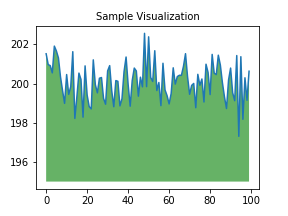

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Sổ tay trên Colab thực thi mã trên các máy chủ đám mây của Google. Nhờ đó, bạn có thể tận dụng sức mạnh của phần cứng Google, bao gồm cả <a href="#using-accelerated-hardware">GPU và TPU</a>, cho dù máy tính của bạn mạnh hay yếu. Bạn chỉ cần một trình duyệt.

Ví dụ: nếu đang chờ mã <strong>pandas</strong> chạy xong và muốn tăng tốc, thì bạn có thể chuyển sang một Thời gian chạy GPU và sử dụng các thư viện như <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> giúp tăng tốc mà không thay đổi mã.

Để tìm hiểu thêm về cách chạy mã pandas nhanh hơn trên Colab, hãy xem <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">hướng dẫn 10 phút</a> hoặc
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">bản minh hoạ cách phân tích dữ liệu thị trường chứng khoán Hoa Kỳ</a>.

<div class="markdown-google-sans">

## Máy học
</div>

Với Colab, chỉ cần sử dụng <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">một vài dòng mã</a> là bạn có thể nhập tập dữ liệu hình ảnh, huấn luyện một thuật toán phân loại hình ảnh dựa trên tập dữ liệu đó và đánh giá mô hình này.

Colab được sử dụng rộng rãi trong cộng đồng máy học với các ứng dụng như:
- Bắt đầu sử dụng TensorFlow
- Phát triển và huấn luyện mạng nơron
- Thử nghiệm có sử dụng TPU
- Phổ biến nghiên cứu về AI &#40;trí tuệ nhân tạo&#41;
- Tạo hướng dẫn

Để xem các sổ tay mẫu trên Colab minh họa các ứng dụng dùng mô hình máy học, hãy xem <a href="#machine-learning-examples">các ví dụ về máy học</a> ở bên dưới.

<div class="markdown-google-sans">

## Tài nguyên khác

### Làm việc với Sổ tay trong Colab

</div>

- [Tổng quan về Colab](/notebooks/basic_features_overview.ipynb)
- [Hướng dẫn sử dụng Markdown](/notebooks/markdown_guide.ipynb)
- [Nhập thư viện và cài đặt phần phụ thuộc](/notebooks/snippets/importing_libraries.ipynb)
- [Lưu và tải sổ tay trong GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Biểu mẫu tương tác](/notebooks/forms.ipynb)
- [Tiện ích tương tác](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Làm việc với dữ liệu
</div>

- [Tải dữ liệu: Drive, Trang tính và Google Cloud Storage](/notebooks/io.ipynb)
- [Biểu đồ: trực quan hóa dữ liệu](/notebooks/charts.ipynb)
- [Bắt đầu sử dụng BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Học máy

<div>

Đây là một số sổ tay liên quan đến công nghệ Học máy, bao gồm cả khoá học trực tuyến về công nghệ Học máy của Google. Hãy xem <a href="https://developers.google.com/machine-learning/crash-course/">trang web đầy đủ của khoá học</a> để biết thêm thông tin.
- [Giới thiệu về Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Giới thiệu về RAPIDS cuDF để tăng tốc pandas](https://nvda.ws/rapids-cudf)
- [Bắt đầu sử dụng chế độ tăng tốc của cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Sử dụng phần cứng tăng tốc
</div>

- [Huấn luyện một CNN phân loại chữ số viết tay trên tập dữ liệu MNIST bằng Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Huấn luyện một Vision Transformer &#40;ViT&#41; phân loại hình ảnh bằng JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Phân loại văn bản bằng mô hình ngôn ngữ Transformer sử dụng JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Ví dụ điển hình

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Huấn luyện một mô hình ngôn ngữ miniGPT bằng JAX AI Stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Tinh chỉnh LoRA/QLoRA cho LLM bằng Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Tinh chỉnh Gemma một cách hiệu quả về tham số bằng LoRA và QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Tải các điểm kiểm tra của Hugging Face Transformers</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Lượng tử hoá số nguyên 8 bit trong Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Huấn luyện và suy luận bằng Float8 với một mô hình Transformer đơn giản</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Huấn luyện trước một Transformer từ đầu bằng KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Mạng nơron tích chập MNIST đơn giản</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Phân loại hình ảnh từ đầu bằng Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Phân loại hình ảnh bằng KerasHub</a>
